In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Better plotting style
sns.set(style="whitegrid", context="notebook")

# Load dataset from current EXP5 folder
data_path = Path("wine-clustering.csv")
data = pd.read_csv(data_path)

# Normalize column names from the CSV header
data.columns = data.columns.str.strip().str.replace(" ", "_")

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


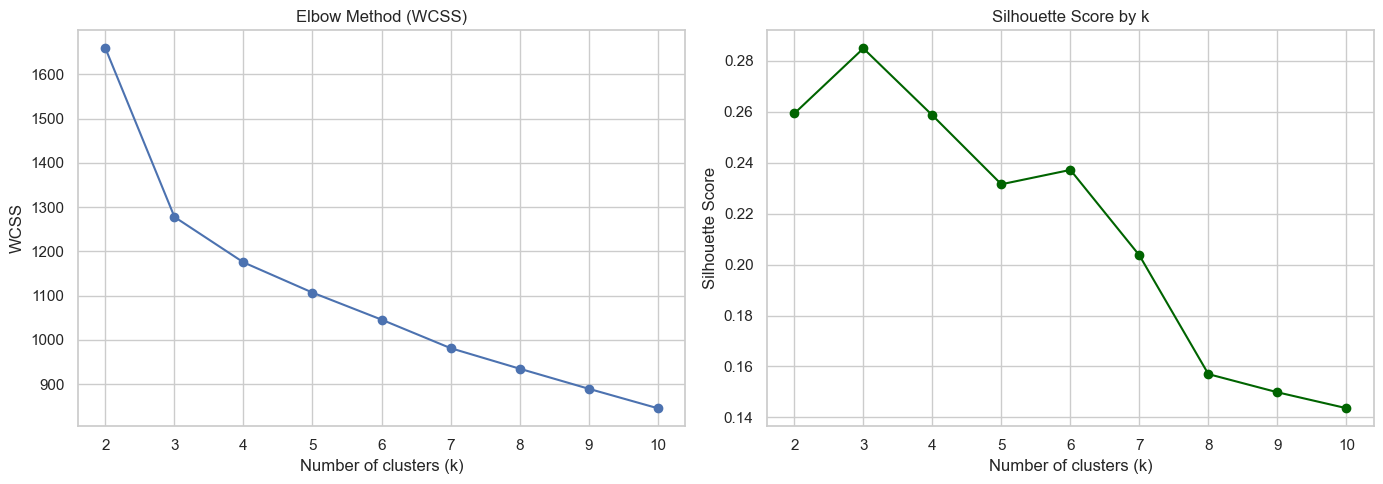

In [7]:
# Scale features before clustering
feature_cols = data.columns.tolist()
X = data[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method + silhouette scores to support k=3
wcss = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = model.fit_predict(X_scaled)
    wcss.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_values), wcss, marker="o")
ax[0].set_title("Elbow Method (WCSS)")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("WCSS")

ax[1].plot(list(k_values), sil_scores, marker="o", color="darkgreen")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [8]:
# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)

print("Explained variance ratio (2 PCs):", pca.explained_variance_ratio_)


Explained variance ratio (2 PCs): [0.36198848 0.1920749 ]


In [9]:
# Final clustering with k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans3.fit_predict(X_scaled)

# Save cluster labels
data["cluster"] = clusters

print("Cluster counts:")
print(data["cluster"].value_counts().sort_index())


Cluster counts:
cluster
0    65
1    51
2    62
Name: count, dtype: int64


In [10]:
# Map numeric clusters to wine names using mean Color_Intensity
cluster_color_mean = data.groupby("cluster")["Color_Intensity"].mean().sort_values()

# Lowest -> White, Middle -> Rose, Highest -> Red
ordered_clusters = cluster_color_mean.index.tolist()
cluster_to_name = {
    ordered_clusters[0]: "White Wine",
    ordered_clusters[1]: "Rose Wine",
    ordered_clusters[2]: "Red Wine",
}

data["wine_type"] = data["cluster"].map(cluster_to_name)

print("Cluster to Wine Type mapping:")
print(cluster_to_name)

print("\nWine type counts:")
print(data["wine_type"].value_counts())


Cluster to Wine Type mapping:
{0: 'White Wine', 2: 'Rose Wine', 1: 'Red Wine'}

Wine type counts:
wine_type
White Wine    65
Rose Wine     62
Red Wine      51
Name: count, dtype: int64


In [11]:
# Compute centroids in original and PCA spaces
centroids_scaled = kmeans3.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

# Cluster profile in original feature scale
centroids_original = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=feature_cols
)
centroids_original["cluster"] = centroids_original.index
centroids_original["wine_type"] = centroids_original["cluster"].map(cluster_to_name)

display(centroids_original.sort_values("wine_type"))


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster,wine_type
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,1,Red Wine
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,2,Rose Wine
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,0,White Wine


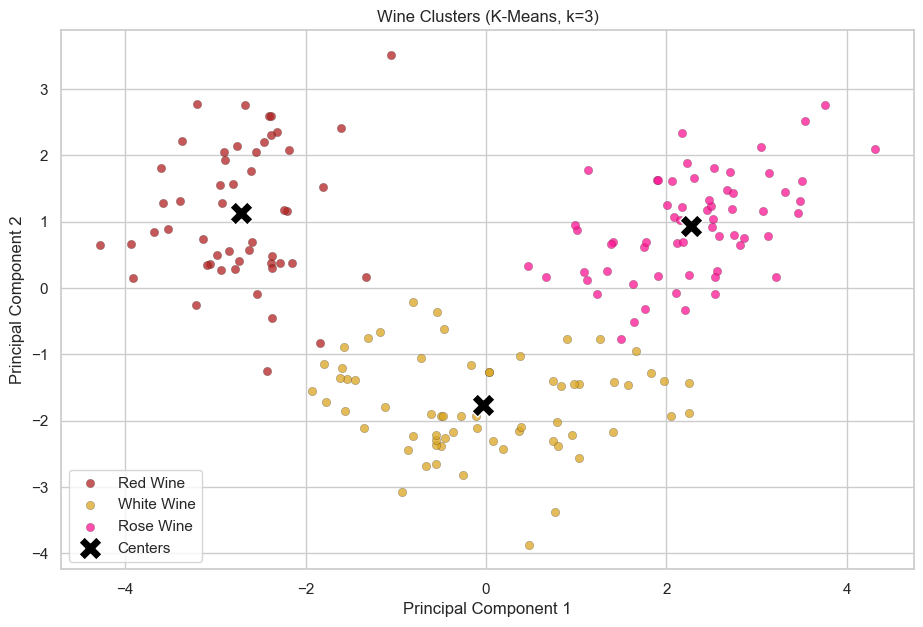

Saved labeled data to: wine-supervised-from-clustering.csv


In [12]:
# Visualize clusters with wine names and centroid markers
plt.figure(figsize=(11, 7))

palette = {
    "Red Wine": "firebrick",
    "White Wine": "goldenrod",
    "Rose Wine": "deeppink",
}

for wt in ["Red Wine", "White Wine", "Rose Wine"]:
    idx = data["wine_type"] == wt
    plt.scatter(
        pca_data[idx, 0],
        pca_data[idx, 1],
        c=palette[wt],
        label=wt,
        alpha=0.75,
        edgecolors="k",
        linewidths=0.2,
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=280,
    c="black",
    edgecolors="white",
    linewidths=1.0,
    label="Centers",
    zorder=10,
 )

plt.title("Wine Clusters (K-Means, k=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# Save labeled dataset
output_file = "wine-supervised-from-clustering.csv"
data.to_csv(output_file, index=False)
print(f"Saved labeled data to: {output_file}")